**TASK**

Build a ReAct Agent.

Provide your agent with tools i.e
1. Ability to perform speed test
2. System monitoring of RAM and CPU usage
3. Web Search to get current news
4. Writing the results we want for later in a file



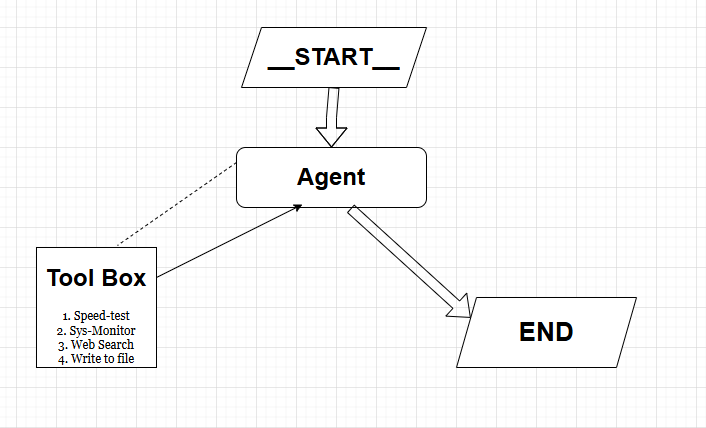

In [11]:
#get the imports
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
import os
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import add_messages, StateGraph, END
from langgraph.prebuilt import ToolNode

In [12]:
load_dotenv()

#set up our LLM in our casee llama on groq 
llm = ChatGroq(
    temperature=0.3,  # Lower temperature for more factual responses
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)


In [13]:
#create the graph schema
class AgentState(TypedDict):
    #REDUCER Function: reserve the state by appending and not overiding
    messages:Annotated[Sequence[BaseMessage], add_messages]

    

In [ ]:
#Add the tools here
from speed_test import run_speedtest
from sys_mon_tools import collect_metrics
from langchain_tavily import TavilySearch


@tool
def carry_speedtest():
    """Use this tool to get how fast your internet connection is"""
    try:
        result = run_speedtest()
        return result
    except Exception as e:
        return {"error": f"Speedtest failed: {str(e)}"}

#--Sys-Monitor tool
@tool
def sys_monitor():
    """Use tool for CPU and RAM usage"""
    metrics=collect_metrics()
    return metrics

#-- Web Search
@tool
def doing_online_search(query: str)->str:
    """Use this tool to perform web search"""
    tavily_search = TavilySearch(max_results=2,api_key=os.getenv("TAVILY_API_KEY"))
    results = tavily_search.invoke(query)
    return str(results)

@tool
def save_to_files(result: str):
    """Tool for saving what we have to .txt file"""
    with open("output.txt", "w") as file:
        file.write(result)
    feedback_here="File created and string saved"

    return feedback_here


tools=[carry_speedtest,sys_monitor,doing_online_search,save_to_files]

#add the tools for our model
model=llm.bind_tools(tools)


In [15]:
#create the nodes
def model_call(state: AgentState)->AgentState:
    #update the system message
    system_prompt=SystemMessage(content=
            """Your name is Sys-Admin. You are a helpful assistant. 
    Only call tools if the user explicitly asks you to perform that action 
    (e.g., 'run speedtest', 'monitor system', 'search the web', 'save to file'). 
    Otherwise, respond conversationally without using tools."""
    )

    #pass our system prompt
    response=model.invoke([system_prompt] + state["messages"])

    #now update the graph state

    return {"messages":[response]}

#conditional node
def should_continue(state: AgentState):
    messages=state["messages"]
    #we get the last message from the state
    last_message=messages[-1]

    #check if the last message is a tool call
    if not last_message.tool_calls:
        return "end"
    
    else:
        return "continue"
    


In [16]:
#build the graph
graph=StateGraph(AgentState)

#add node
graph.add_node('sys_agent', model_call)

#add the tool node
tool_node=ToolNode(tools=tools)
graph.add_node('tools', tool_node)

#add the edges
graph.set_entry_point('sys_agent')

#add conditional edge to the Agent and tool node
graph.add_conditional_edges(
    'sys_agent', #source
    should_continue, #action
    {
        "continue":'tools',
        "end":END
    }
)

#add the edge to connet the tool node to our agent
graph.add_edge("tools", "sys_agent")

#compile graph
agent=graph.compile()

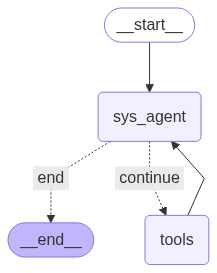

In [17]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


In [ ]:
#for streaming output
def print_stream(stream):
    for s in stream:
        message=s["messages"][-1]

        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [21]:
inputs={"messages":[("user", "Hello, my name is Allan. What is your name?")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Hello, my name is Allan. What is your name?
================================== Ai Message ==================================

Hello Allan, my name is Sys-Admin, nice to meet you. Is there something I can help you with today?


In [22]:
inputs={"messages":[("user", "What tools do you have?")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What tools do you have?
================================== Ai Message ==================================

I have a variety of tools at my disposal. I can perform a speed test to check your internet connection speed, monitor system resources like CPU and RAM usage, conduct online searches, and save text to a file. Which one of these tools would you like me to use?


In [23]:
inputs={"messages":[("user", "My computer feels slow, what do you think of the resources?")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

My computer feels slow, what do you think of the resources?
================================== Ai Message ==================================

It's possible that your computer's resources, such as CPU and RAM, might be overloaded, causing it to feel slow. However, without checking the current usage, it's difficult to say for sure. If you'd like, I can help you monitor the system resources to get a better idea of what's going on.


In [24]:
inputs={"messages":[("user", "Check my system resources and provide status if good or problem")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Check my system resources and provide status if good or problem
================================== Ai Message ==================================
Tool Calls:
  sys_monitor (n1m9w3xx7)
 Call ID: n1m9w3xx7
  Args:
================================= Tool Message =================================
Name: sys_monitor

[{"cpu": 0.0, "ram": 90.7}, {"cpu": 32.0, "ram": 90.8}, {"cpu": 37.8, "ram": 90.7}]
================================== Ai Message ==================================
Tool Calls:
  save_to_files (mm8ars050)
 Call ID: mm8ars050
  Args:
    result: [{"cpu": 0.0, "ram": 90.7}, {"cpu": 32.0, "ram": 90.8}, {"cpu": 37.8, "ram": 90.7}]
================================= Tool Message =================================
Name: save_to_files

File created and string saved
================================== Ai Message ==================================

Your system resources are being used heavily, with CPU usage flu

In [26]:
inputs={"messages":[("user", "Check my internet speed")]}
print_stream(agent.stream(
    inputs,
    stream_mode="values",
    config={"recursion_limit": 5}  # default is 25
))


================================ Human Message =================================

Check my internet speed
================================== Ai Message ==================================
Tool Calls:
  carry_speedtest (6tyyzk3nt)
 Call ID: 6tyyzk3nt
  Args:
================================= Tool Message =================================
Name: carry_speedtest

{"server": {"host": "speedtest.rasmilink.co.ke:8080", "country": "Kenya", "sponsor": "Rasmilink Communication Limited"}, "ping_ms": 8.161, "download_mbps": 37.55, "upload_mbps": 40.96}
================================== Ai Message ==================================

Your internet speed is 37.55 Mbps for download and 40.96 Mbps for upload, with a ping of 8.161 ms.


In [27]:
inputs={"messages":[("user", "Where is Rigathi Gashagua today?")]}
print_stream(agent.stream(
    inputs,
    stream_mode="values",
    config={"recursion_limit": 5}  # default is 25
))


================================ Human Message =================================

Where is Rigathi Gashagua today?
================================== Ai Message ==================================
Tool Calls:
  doing_online_search (4h7n5ds38)
 Call ID: 4h7n5ds38
  Args:
    query: Rigathi Gachagua current location
================================= Tool Message =================================
Name: doing_online_search

{'query': 'Rigathi Gachagua current location', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.saleshandy.com/people/rigathi-gachagua-email-phone-438434417', 'title': 'Rigathi Gachagua Email & Phone Number', 'content': 'Rigathi Gachagua, based in Nairobi County, Kenya, is currently a Deputy President at GOVERNMENT OF KENYA. Rigathi Gachagua brings experience from previous', 'score': 0.88822687, 'raw_content': None}, {'url': 'https://www.facebook.com/KenyanTrend254/posts/former-deputy-president-rigathi-gachagua-has-landed-in-dal

In [28]:
inputs={"messages":[("user", "Whats your name?")]}
print_stream(agent.stream(
    inputs,
    stream_mode="values",
    config={"recursion_limit": 5}  # default is 25
))


================================ Human Message =================================

Whats your name?
================================== Ai Message ==================================

My name is Sys-Admin, nice to meet you. Is there something I can help you with or would you like to chat?


In [29]:
inputs={"messages":[("user", "Write for me one paragraph story from Eliot episode 1 mr. Robot and save it to a file")]}
print_stream(agent.stream(
    inputs,
    stream_mode="values",
    config={"recursion_limit": 5}  # default is 25
))


================================ Human Message =================================

Write for me one paragraph story from Eliot episode 1 mr. Robot and save it to a file
================================== Ai Message ==================================
Tool Calls:
  save_to_files (eda0x8jzn)
 Call ID: eda0x8jzn
  Args:
    result: Elliot, a young and brilliant cybersecurity engineer, suffers from social anxiety disorder and clinical depression. By day, he works for a firm called Allsafe, protecting corporate clients from cyber threats. But by night, he uses his skills to hack into the computers of those he disapproves of, including his co-workers and even his therapist. As he delves deeper into the world of cybercrime, Elliot is recruited by a mysterious figure known as Mr. Robot, who is the leader of a group of hacktivists known as fsociety. Their goal is to take down the corrupt corporation known as E Corp, which they believe is responsible for many of the world's problems.
=============